In [20]:
print("BUSI")

BUSI


In [21]:

import numpy as np 
import pandas as pd 

import os

dataset_path = "Dataset_BUSI_with_GT"

for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))


Dataset_BUSI_with_GT\benign\benign (1).png
Dataset_BUSI_with_GT\benign\benign (1)_mask.png
Dataset_BUSI_with_GT\benign\benign (10).png
Dataset_BUSI_with_GT\benign\benign (10)_mask.png
Dataset_BUSI_with_GT\benign\benign (100).png
Dataset_BUSI_with_GT\benign\benign (100)_mask.png
Dataset_BUSI_with_GT\benign\benign (100)_mask_1.png
Dataset_BUSI_with_GT\benign\benign (101).png
Dataset_BUSI_with_GT\benign\benign (101)_mask.png
Dataset_BUSI_with_GT\benign\benign (102).png
Dataset_BUSI_with_GT\benign\benign (102)_mask.png
Dataset_BUSI_with_GT\benign\benign (103).png
Dataset_BUSI_with_GT\benign\benign (103)_mask.png
Dataset_BUSI_with_GT\benign\benign (104).png
Dataset_BUSI_with_GT\benign\benign (104)_mask.png
Dataset_BUSI_with_GT\benign\benign (105).png
Dataset_BUSI_with_GT\benign\benign (105)_mask.png
Dataset_BUSI_with_GT\benign\benign (106).png
Dataset_BUSI_with_GT\benign\benign (106)_mask.png
Dataset_BUSI_with_GT\benign\benign (107).png
Dataset_BUSI_with_GT\benign\benign (107)_mask.png
Data

In [22]:
import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [24]:
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [25]:
from torchvision.datasets import ImageFolder

class CleanImageFolder(ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform)
        self.samples = [
            (p,y) for p,y in self.samples if "_mask" not in p
        ]

dataset_path = "Dataset_BUSI_with_GT"

dataset = CleanImageFolder(dataset_path, train_transforms)

print(dataset.classes)


['benign', 'malignant', 'normal']


In [26]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

val_ds.dataset.transform = test_transforms
test_ds.dataset.transform = test_transforms

In [27]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

In [28]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = [label for _, label in train_ds]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class Weights:", class_weights)

Class Weights: tensor([0.5871, 1.2639, 1.9783])


In [ ]:
# MODEL 

class ClassicalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(32, 3)  
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


# USING CLASSICAL MODEL 

model = ClassicalCNN().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [32]:
def train(model, loader, epochs=40):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(loader):.4f}")

In [34]:
train(model, train_loader, epochs=40)

Epoch 1/40 - Loss: 0.8877
Epoch 2/40 - Loss: 0.8720
Epoch 3/40 - Loss: 0.8697
Epoch 4/40 - Loss: 0.8788
Epoch 5/40 - Loss: 0.8894
Epoch 6/40 - Loss: 0.8568
Epoch 7/40 - Loss: 0.8642
Epoch 8/40 - Loss: 0.8704
Epoch 9/40 - Loss: 0.8646
Epoch 10/40 - Loss: 0.8688
Epoch 11/40 - Loss: 0.8418
Epoch 12/40 - Loss: 0.8548
Epoch 13/40 - Loss: 0.8498
Epoch 14/40 - Loss: 0.8492
Epoch 15/40 - Loss: 0.8343
Epoch 16/40 - Loss: 0.8397
Epoch 17/40 - Loss: 0.8293
Epoch 18/40 - Loss: 0.8408
Epoch 19/40 - Loss: 0.8590
Epoch 20/40 - Loss: 0.8413
Epoch 21/40 - Loss: 0.8222
Epoch 22/40 - Loss: 0.8433
Epoch 23/40 - Loss: 0.8417
Epoch 24/40 - Loss: 0.8173
Epoch 25/40 - Loss: 0.8231
Epoch 26/40 - Loss: 0.8492
Epoch 27/40 - Loss: 0.8464
Epoch 28/40 - Loss: 0.7970
Epoch 29/40 - Loss: 0.8100
Epoch 30/40 - Loss: 0.8009
Epoch 31/40 - Loss: 0.8290
Epoch 32/40 - Loss: 0.8105
Epoch 33/40 - Loss: 0.8025
Epoch 34/40 - Loss: 0.8417
Epoch 35/40 - Loss: 0.7973
Epoch 36/40 - Loss: 0.8201
Epoch 37/40 - Loss: 0.8094
Epoch 38/4

In [35]:
torch.save(model.state_dict(), "busi_cnn.pth")

In [36]:
def evaluate(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, 1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    print(classification_report(
        y_true, y_pred,
        target_names=dataset.classes
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=dataset.classes,
                yticklabels=dataset.classes,
                cmap="Blues")
    plt.show()

    unique, counts = np.unique(y_pred, return_counts=True)
    print("Prediction distribution:", dict(zip(unique, counts)))

              precision    recall  f1-score   support

      benign       0.79      0.52      0.62        66
   malignant       0.53      0.31      0.39        29
      normal       0.33      0.86      0.48        22

    accuracy                           0.53       117
   macro avg       0.55      0.56      0.50       117
weighted avg       0.64      0.53      0.54       117



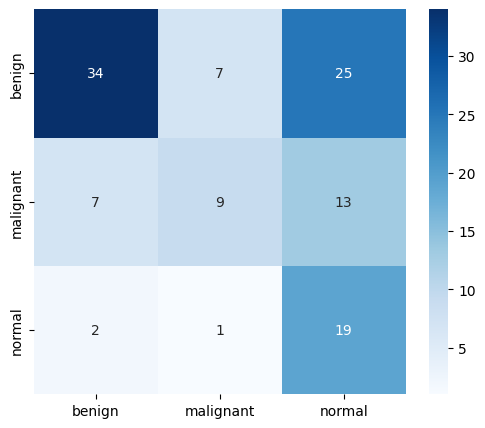

Prediction distribution: {np.int64(0): np.int64(43), np.int64(1): np.int64(17), np.int64(2): np.int64(57)}


In [37]:
evaluate(model, test_loader)